# Job Market Micro Professions Analysis Using NLP and Clustering

## Research Methodology

This notebook analyzes job postings in the data science field to identify emerging micro professions using natural language processing and unsupervised machine learning.

**Key Methodological Steps:**
- **Data Collection:** Job posting data from various sources filtered for data science related roles
- **Text Processing:** Clean and normalize job descriptions using regex and text preprocessing
- **Semantic Embedding:** Transform job descriptions into numerical vectors using transformer based sentence embeddings
- **Clustering Analysis:** Apply DBSCAN and K Means algorithms to group similar job postings
- **Temporal Tracking:** Monitor how job clusters evolve over time using quarterly windows
- **Skill Extraction:** Identify and compare technical skills across different job clusters
- **Interpretation:** Use TF IDF to extract meaningful terms that define each cluster

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# NLP and ML libraries
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cosine
import re

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load job data
csv_path = '../data/parsed_jobs.csv'
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (40435, 17)

Column names: ['job_id', 'job_title', 'job_description', 'company_name', 'industry', 'location', 'latitude', 'longitude', 'job_function', 'skills', 'degree_requirement', 'visa_sponsorship', 'time_posted_parsed', 'application_link', 'num_applicants_int', 'work_mode', 'scraped_at']

First few rows:
       job_id                                          job_title  \
0  4270966411  Data Science Project Intern(TikTok Shop-Supply...   
1  4299426023   Supply Chain Data Analytics Intern - Summer 2026   
2  4281380175                           IT Data Analytics Intern   
3  4342484646                                     IT Intern (AI)   
4  4342464542            Intern, Business Transformation Analyst   

                                     job_description  \
0  ResponsibilitiesThe commerce data science team...   
1  Pay found in job postRetrieved from the descri...   
2  DescriptionA Data Analyst Intern is responsibl...   
3  Lensa is a career site that helps job 

## Filtering and Preprocessing

- Filter dataset for target data science roles (data scientist, ML engineer, data analyst, etc.)
- Identify and clean job description text
- Remove HTML tags and extra whitespace
- Prepare clean text for embedding

In [3]:
# Define target job titles
target_keywords = ['data scientist', 'ml engineer', 'machine learning', 'data analyst', 
                   'data engineer', 'analytics engineer', 'ai engineer', 'nlp engineer']

# Find the column that contains job titles
title_col = None
for col in ['title', 'job_title', 'position', 'role']:
    if col in df.columns:
        title_col = col
        break

if title_col is None:
    print("Available columns:", df.columns.tolist())
    print("Please specify the correct title column name")
else:
    print(f"Using column: {title_col}")

# Filter for target roles (case insensitive)
mask = df[title_col].str.lower().str.contains('|'.join(target_keywords), na=False, regex=True)
df_filtered = df[mask].copy()

print(f"\nFiltered dataset shape: {df_filtered.shape}")
print(f"Percentage of data retained: {len(df_filtered)/len(df)*100:.1f}%")
print(f"\nSample of filtered titles:")
print(df_filtered[title_col].value_counts().head(10))

Using column: job_title

Filtered dataset shape: (5005, 17)
Percentage of data retained: 12.4%

Sample of filtered titles:
job_title
Data Analyst Intern                                                                    1212
Machine Learning Intern - Summer 2026                                                   159
Data Scientist Intern: 2026                                                             121
Data Scientist Intern (Remote)                                                          113
Associate Data Scientist Intern 2026                                                     89
Data Engineer Intern                                                                     87
2026 Summer Intern - AI/ML Engineer - Cloud & Developer Infrastructure (Bachelor's)      84
Data Scientist Intern                                                                    82
2026 Summer Internship Program: Data & Analytics Engineer Intern                         79
Data Engineering Intern                

In [4]:
# Identify job description column
desc_col = None
for col in ['description', 'job_description', 'content', 'text', 'body']:
    if col in df_filtered.columns:
        desc_col = col
        break

if desc_col is None:
    print("Available columns:", df_filtered.columns.tolist())
    print("Please specify the correct description column name")
else:
    print(f"Using column: {desc_col}")

# Remove rows with missing descriptions
df_filtered = df_filtered.dropna(subset=[desc_col])
print(f"\nAfter removing missing descriptions: {len(df_filtered)} rows")

# Clean text: remove HTML tags, extra whitespace
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['cleaned_description'] = df_filtered[desc_col].apply(clean_text)
print("\nSample cleaned description:")
print(df_filtered['cleaned_description'].iloc[0][:500])

Using column: job_description

After removing missing descriptions: 5005 rows

Sample cleaned description:
Company DescriptionAbbVie's mission is to discover and deliver innovative medicines and solutions that solve serious health issues today and address the medical challenges of tomorrow. We strive to have a remarkable impact on people's lives across several key therapeutic areas immunology, oncology, neuroscience, and eye care and products and services in our Allergan Aesthetics portfolio. For more information about AbbVie, please visit us atwww.abbvie.com. Follow @abbvie onX,Facebook,Instagram,Yo


## Time Windowing

- Convert posting dates to datetime format
- Filter data to include only jobs posted after November 30, 2024
- Create quarterly and monthly time periods for temporal analysis
- Prepare data for tracking cluster evolution over time

In [5]:

# Convert to datetime
df_filtered['parsed_date'] = pd.to_datetime(df_filtered['time_posted_parsed'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['parsed_date'])

print(f"\nDate range: {df_filtered['parsed_date'].min()} to {df_filtered['parsed_date'].max()}")
print(f"Rows with valid dates: {len(df_filtered)}")



Date range: 2025-12-06 02:09:25.552913-05:00 to 2026-01-03 07:11:09.480753-05:00
Rows with valid dates: 5001


In [6]:
# Filter data to only include jobs posted on or after November 30, 2024
# (Earlier data contains AI-summarized descriptions that would affect clustering quality)
# Make cutoff date timezone-aware to match the parsed dates
cutoff_date = pd.to_datetime('2024-11-30').tz_localize('UTC')

print(f"Before date filtering: {len(df_filtered)} rows")

# Apply date filter
if 'parsed_date' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['parsed_date'] >= cutoff_date]
    print(f"After filtering (>= {cutoff_date.date()}): {len(df_filtered)} rows")
    print(f"New date range: {df_filtered['parsed_date'].min()} to {df_filtered['parsed_date'].max()}")
else:
    print("WARNING: 'parsed_date' column not yet created. Run previous cells first.")

Before date filtering: 5001 rows
After filtering (>= 2024-11-30): 5001 rows
New date range: 2025-12-06 02:09:25.552913-05:00 to 2026-01-03 07:11:09.480753-05:00


In [7]:
# Create time windows 
df_filtered['year_quarter'] = df_filtered['parsed_date'].dt.to_period('Q')
df_filtered['year_month'] = df_filtered['parsed_date'].dt.to_period('M')

print("Quarterly distribution:")
print(df_filtered['year_quarter'].value_counts().sort_index())
print(f"\nNumber of quarters: {df_filtered['year_quarter'].nunique()}")
print(f"Number of months: {df_filtered['year_month'].nunique()}")

Quarterly distribution:
year_quarter
2025Q4    4930
2026Q1      71
Freq: Q-DEC, Name: count, dtype: int64

Number of quarters: 2
Number of months: 2


## Embedding Pipeline

- Load pretrained sentence transformer model for text embeddings
- Generate semantic embeddings for all job descriptions
- Convert text into numerical vectors that capture meaning
- Standardize embeddings for clustering algorithms

In [8]:
# Load sentence transformer model (lightweight, CPU-friendly)
print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading sentence transformer model...
Model loaded successfully
Embedding dimension: 384


In [9]:
# Generate embeddings for job descriptions
# This may take a few minutes depending on dataset size
print(f"Generating embeddings for {len(df_filtered)} job descriptions...")

# Embed full cleaned descriptions
# The model will handle its own tokenization and truncation
embeddings = model.encode(df_filtered['cleaned_description'].tolist(), 
                           show_progress_bar=True, 
                           batch_size=32)

print(f"\nEmbeddings shape: {embeddings.shape}")
df_filtered['embedding'] = [emb for emb in embeddings]

Generating embeddings for 5001 job descriptions...


Batches: 100%|██████████| 157/157 [09:35<00:00,  3.67s/it]


Embeddings shape: (5001, 384)


In [10]:
# Convert embeddings to numpy array for clustering
X = np.array(df_filtered['embedding'].tolist())
print(f"Embedding matrix shape: {X.shape}")

# Standardize embeddings
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled embedding matrix shape: {X_scaled.shape}")

Embedding matrix shape: (5001, 384)
Scaled embedding matrix shape: (5001, 384)


## Clustering Experimentation

- Test DBSCAN algorithm with different hyperparameters (eps and min_samples)
- Test K Means algorithm with different cluster numbers
- Evaluate clustering quality using silhouette score and other metrics
- Select best clustering configuration based on evaluation results

In [11]:
# DBSCAN Clustering with hyperparameter tuning
print("Testing DBSCAN parameters...\n")

dbscan_results = []
eps_values = np.arange(0.3, 1.0, 0.1)
min_samples_values = [5, 10, 15, 20]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1 and n_clusters < len(np.unique(labels)):
            silhouette = silhouette_score(X_scaled, labels)
        else:
            silhouette = -1
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette
        })

dbscan_df = pd.DataFrame(dbscan_results)
print("Top 10 DBSCAN configurations by Silhouette Score:")
print(dbscan_df.nlargest(10, 'silhouette')[['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette']])

Testing DBSCAN parameters...

Top 10 DBSCAN configurations by Silhouette Score:
    eps  min_samples  n_clusters  n_noise  silhouette
0   0.3            5         196      140    0.960874
4   0.4            5         195      140    0.960780
8   0.5            5         195      140    0.960780
12  0.6            5         194      137    0.959053
16  0.7            5         191      137    0.958035
20  0.8            5         189      137    0.957640
24  0.9            5         186      137    0.956929
21  0.8           10         156      399    0.890262
25  0.9           10         153      399    0.889550
17  0.7           10         157      408    0.887078


In [12]:
# Select best DBSCAN configuration
best_dbscan = dbscan_df.nlargest(1, 'silhouette').iloc[0]
dbscan_final = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
df_filtered['dbscan_cluster'] = dbscan_final.fit_predict(X_scaled)

print(f"\nBest DBSCAN Configuration:")
print(f"  eps: {best_dbscan['eps']:.2f}")
print(f"  min_samples: {int(best_dbscan['min_samples'])}")
print(f"  n_clusters: {best_dbscan['n_clusters']:.0f}")
print(f"  n_noise points: {best_dbscan['n_noise']:.0f}")
print(f"  Silhouette Score: {best_dbscan['silhouette']:.3f}")
print(f"\nDBSCAN Cluster Distribution:")
print(df_filtered['dbscan_cluster'].value_counts().sort_index())


Best DBSCAN Configuration:
  eps: 0.30
  min_samples: 5
  n_clusters: 196
  n_noise points: 140
  Silhouette Score: 0.961

DBSCAN Cluster Distribution:
dbscan_cluster
-1      140
 0        5
 1       51
 2       16
 3       37
       ... 
 191     20
 192     20
 193     20
 194      7
 195      5
Name: count, Length: 197, dtype: int64


In [13]:
# K Means Clustering with elbow method
print("Testing K Means with different cluster numbers...\n")

kmeans_results = []
k_values = range(2, min(15, len(df_filtered)//10))  # Reasonable k range

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    
    kmeans_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski
    })

kmeans_df = pd.DataFrame(kmeans_results)
print("K Means evaluation metrics:")
print(kmeans_df)
print(f"\nBest k by Silhouette Score: {kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k']:.0f}")

Testing K Means with different cluster numbers...

K Means evaluation metrics:
     k      inertia  silhouette  davies_bouldin  calinski_harabasz
0    2  1634912.750    0.172022        2.064044         872.868700
1    3  1524952.000    0.184167        2.685127         648.011525
2    4  1446994.625    0.194564        2.571976         544.932697
3    5  1378471.000    0.216804        2.209139         491.017003
4    6  1361898.375    0.211396        2.325710         409.668664
5    7  1285622.375    0.240414        2.156034         410.954930
6    8  1272602.750    0.222839        2.377489         363.078552
7    9  1217544.500    0.256894        2.405124         360.210244
8   10  1186885.750    0.267132        2.308991         342.716998
9   11  1141302.750    0.286148        2.130600         340.629354
10  12  1129248.750    0.283220        2.307217         317.747824
11  13  1112666.000    0.288807        2.194158         301.744981
12  14  1067474.875    0.316358        2.149345   

In [14]:
# Select best K Means configuration
best_k = int(kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k'])
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_filtered['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

best_silhouette = kmeans_df['silhouette'].max()
print(f"\nBest K Means Configuration:")
print(f"  k: {best_k}")
print(f"  Silhouette Score: {best_silhouette:.3f}")
print(f"\nK Means Cluster Distribution:")
print(df_filtered['kmeans_cluster'].value_counts().sort_index())


Best K Means Configuration:
  k: 14
  Silhouette Score: 0.316

K Means Cluster Distribution:
kmeans_cluster
0     245
1     275
2     249
3     304
4     893
5     323
6     147
7     490
8     361
9     232
10     90
11    110
12    491
13    791
Name: count, dtype: int64


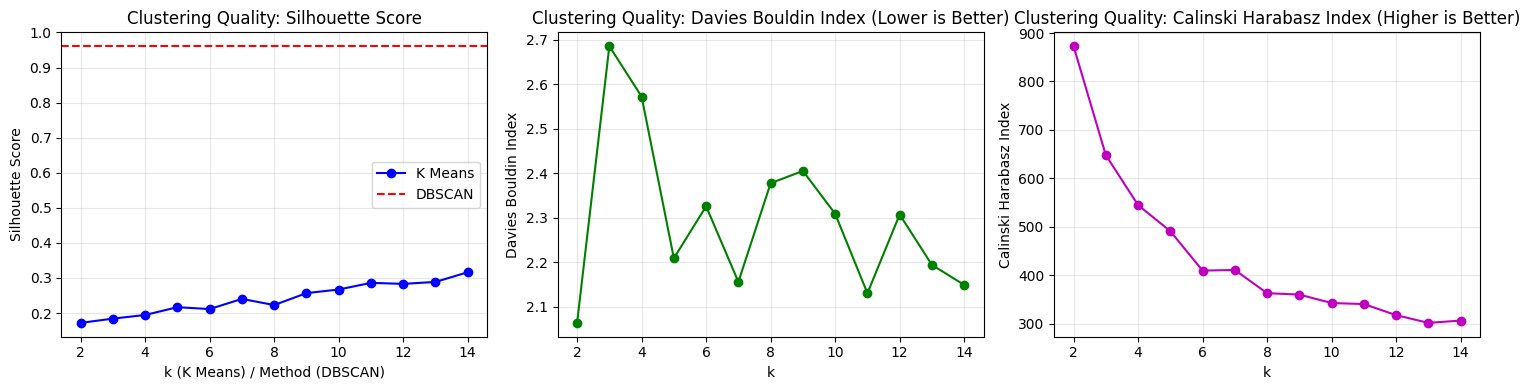

Clustering evaluation metrics plotted


In [15]:
# Visualization: Clustering evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Silhouette comparison
axes[0].plot(kmeans_df['k'], kmeans_df['silhouette'], 'bo-', label='K Means')
axes[0].axhline(best_dbscan['silhouette'], color='r', linestyle='--', label='DBSCAN')
axes[0].set_xlabel('k (K Means) / Method (DBSCAN)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Clustering Quality: Silhouette Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Davies Bouldin comparison (lower is better)
axes[1].plot(kmeans_df['k'], kmeans_df['davies_bouldin'], 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies Bouldin Index')
axes[1].set_title('Clustering Quality: Davies Bouldin Index (Lower is Better)')
axes[1].grid(True, alpha=0.3)

# Calinski Harabasz (higher is better)
axes[2].plot(kmeans_df['k'], kmeans_df['calinski_harabasz'], 'mo-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski Harabasz Index')
axes[2].set_title('Clustering Quality: Calinski Harabasz Index (Higher is Better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Clustering evaluation metrics plotted")

## Temporal Analysis

- Track how clusters evolve over time (quarterly)
- Calculate cluster stability metrics (lifespan, volatility)
- Identify emerging vs declining job types
- Visualize cluster distribution changes over time

In [16]:
# Analyze cluster evolution over time (quarterly)
temporal_dist = df_filtered.groupby(['year_quarter', 'kmeans_cluster']).size().reset_index(name='count')

# Create pivot table for temporal tracking
temporal_pivot = temporal_dist.pivot_table(index='year_quarter', 
                                            columns='kmeans_cluster', 
                                            values='count', 
                                            fill_value=0)
print("Cluster Distribution Over Time (Quarterly):")
print(temporal_pivot)

Cluster Distribution Over Time (Quarterly):
kmeans_cluster     0      1      2      3      4      5      6      7      8   \
year_quarter                                                                    
2025Q4          239.0  275.0  249.0  304.0  879.0  323.0  147.0  481.0  354.0   
2026Q1            6.0    0.0    0.0    0.0   14.0    0.0    0.0    9.0    7.0   

kmeans_cluster     9     10     11     12     13  
year_quarter                                      
2025Q4          232.0  90.0  110.0  456.0  791.0  
2026Q1            0.0   0.0    0.0   35.0    0.0  


In [17]:
# Calculate cluster stability metrics
cluster_stats = []

for cluster_id in temporal_pivot.columns:
    counts = temporal_pivot[cluster_id]
    first_appearance = counts[counts > 0].index[0] if any(counts > 0) else None
    last_appearance = counts[counts > 0].index[-1] if any(counts > 0) else None
    total_postings = counts.sum()
    avg_size = counts[counts > 0].mean() if any(counts > 0) else 0
    volatility = counts[counts > 0].std() if len(counts[counts > 0]) > 1 else 0
    
    cluster_stats.append({
        'cluster_id': cluster_id,
        'first_appearance': first_appearance,
        'last_appearance': last_appearance,
        'lifespan_quarters': (last_appearance - first_appearance).n if first_appearance and last_appearance else 0,
        'total_postings': total_postings,
        'avg_size': avg_size,
        'volatility': volatility
    })

cluster_stats_df = pd.DataFrame(cluster_stats).sort_values('total_postings', ascending=False)
print("\nCluster Stability and Evolution Metrics:")
print(cluster_stats_df)


Cluster Stability and Evolution Metrics:
    cluster_id first_appearance last_appearance  lifespan_quarters  \
4            4           2025Q4          2026Q1                  1   
13          13           2025Q4          2025Q4                  0   
12          12           2025Q4          2026Q1                  1   
7            7           2025Q4          2026Q1                  1   
8            8           2025Q4          2026Q1                  1   
5            5           2025Q4          2025Q4                  0   
3            3           2025Q4          2025Q4                  0   
1            1           2025Q4          2025Q4                  0   
2            2           2025Q4          2025Q4                  0   
0            0           2025Q4          2026Q1                  1   
9            9           2025Q4          2025Q4                  0   
6            6           2025Q4          2025Q4                  0   
11          11           2025Q4          2025Q4 

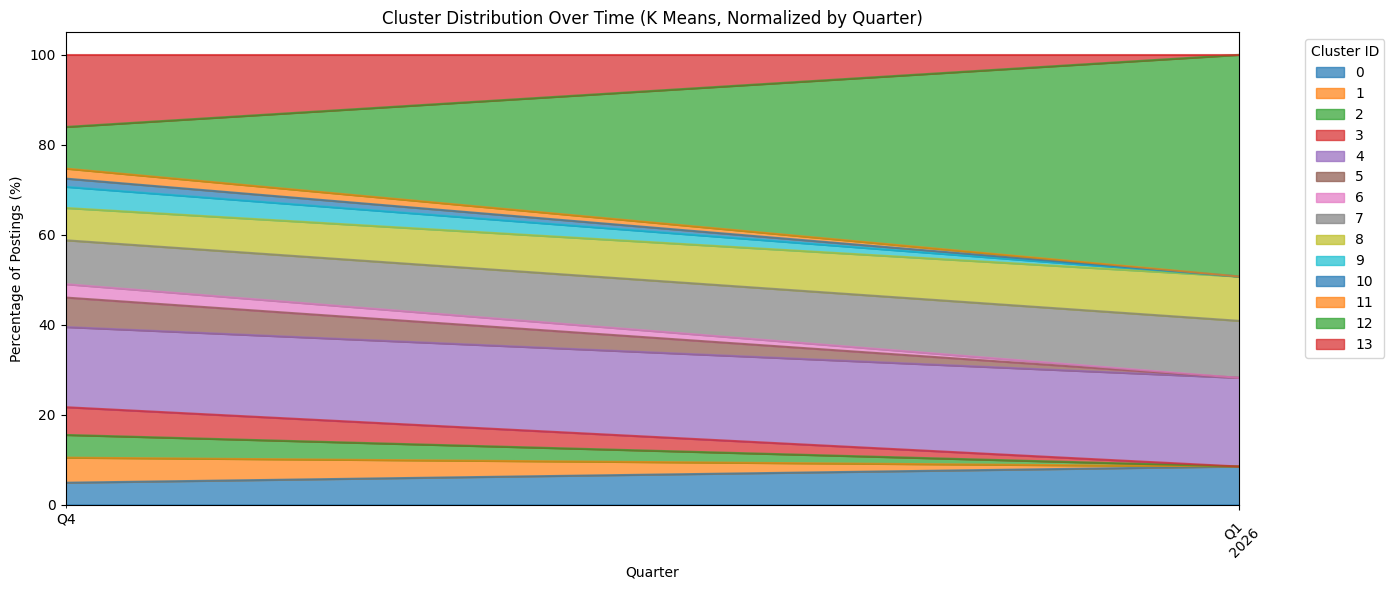

In [18]:
# Visualization: Temporal cluster evolution
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize by quarter total for percentage view
temporal_normalized = temporal_pivot.div(temporal_pivot.sum(axis=1), axis=0) * 100

temporal_normalized.plot(kind='area', ax=ax, alpha=0.7)
ax.set_xlabel('Quarter')
ax.set_ylabel('Percentage of Postings (%)')
ax.set_title('Cluster Distribution Over Time (K Means, Normalized by Quarter)')
ax.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation using TF IDF and Labeling

- Extract top terms for each cluster using TF IDF vectorization
- Identify most important words and phrases that define each cluster
- Manually assign semantic labels to clusters based on top terms
- Create human readable cluster descriptions

In [19]:
# Extract top terms for each cluster using TF IDF
from sklearn.feature_extraction.text import TfidfVectorizer

print("Computing TF IDF for cluster interpretation...\n")

cluster_interpretations = {}

for cluster_id in sorted(df_filtered['kmeans_cluster'].unique()):
    # Get descriptions for this cluster
    cluster_docs = df_filtered[df_filtered['kmeans_cluster'] == cluster_id]['cleaned_description'].tolist()
    
    if len(cluster_docs) < 3:  # Skip very small clusters
        continue
    
    # Compute TF IDF
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 2), stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    
    # Get average TF IDF scores
    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [tfidf.get_feature_names_out()[i] for i in top_indices]
    
    cluster_interpretations[cluster_id] = {
        'top_terms': top_terms,
        'size': len(cluster_docs),
        'mean_tfidf_scores': mean_tfidf[top_indices]
    }

print("Cluster Interpretations (Top Terms by TF IDF):")
for cluster_id, info in cluster_interpretations.items():
    print(f"\nCluster {cluster_id} (n={info['size']}):")
    print(f"  Terms: {', '.join(info['top_terms'][:5])}")

Computing TF IDF for cluster interpretation...

Cluster Interpretations (Top Terms by TF IDF):

Cluster 0 (n=245):
  Terms: data, ai, experience, peraton, 000

Cluster 1 (n=275):
  Terms: ai, ml, kensho, data, lensa

Cluster 2 (n=249):
  Terms: data, learning, tiktok, ai, machine learning

Cluster 3 (n=304):
  Terms: data, ibm, business, science, technical

Cluster 4 (n=893):
  Terms: data, role, lensa, job, time

Cluster 5 (n=323):
  Terms: data, lensa, job, waystar, work

Cluster 6 (n=147):
  Terms: data, tiktok, experience, company, information

Cluster 7 (n=490):
  Terms: data, experience, work, pay, team

Cluster 8 (n=361):
  Terms: data, job, lensa, takeda, ai

Cluster 9 (n=232):
  Terms: data, netflix, experience, ai, analytics

Cluster 10 (n=90):
  Terms: data, fanduel, work, team, experience

Cluster 11 (n=110):
  Terms: pinterest, learning, machine learning, machine, data

Cluster 12 (n=491):
  Terms: data, work, team, experience, ml

Cluster 13 (n=791):
  Terms: data, work, 

In [20]:
# Manually assign semantic labels to clusters
# (Based on domain expertise and top terms)
cluster_labels = {}

# Example labeling (customize based on your actual clusters)
for cluster_id in sorted(cluster_interpretations.keys()):
    top_terms = cluster_interpretations[cluster_id]['top_terms']
    print(f"\nCluster {cluster_id} - Top terms: {top_terms}")
    # Uncomment and customize:
    # cluster_labels[cluster_id] = "[YOUR LABEL HERE]"

# Manual assignment template
print("\n" + "="*50)
print("Assign semantic labels to clusters based on top terms.")
print("Edit cluster_labels dictionary below:")
print("="*50)

cluster_labels = {
    # cluster_id: 'Semantic Label',
    # Example:
    # 0: 'Analytics and Business Intelligence',
    # 1: 'Machine Learning Engineering',
    # 2: 'Data Pipeline Engineering',
}

print(f"\nCurrent labels: {cluster_labels}")


Cluster 0 - Top terms: ['data', 'ai', 'experience', 'peraton', '000', 'work', 'position', 'benefits', 'risk', 'years']

Cluster 1 - Top terms: ['ai', 'ml', 'kensho', 'data', 'lensa', 'models', 'team', 'technical', 'solutions', 'experience']

Cluster 2 - Top terms: ['data', 'learning', 'tiktok', 'ai', 'machine learning', 'machine', 'work', 'product', 'experience', 'models']

Cluster 3 - Top terms: ['data', 'ibm', 'business', 'science', 'technical', 'ai', 'experience', 'learning', 'lensa', 'work']

Cluster 4 - Top terms: ['data', 'role', 'lensa', 'job', 'time', 'customer', 'work', 'paid', 'position', 'patterns']

Cluster 5 - Top terms: ['data', 'lensa', 'job', 'waystar', 'work', 'jobs', 'information', 'new', 'york', 'team']

Cluster 6 - Top terms: ['data', 'tiktok', 'experience', 'company', 'information', 'mission', 'creativity', 'work', 'people', 'candidates']

Cluster 7 - Top terms: ['data', 'experience', 'work', 'pay', 'team', 'skills', 'range', 'program', '00', 'engineering']

Clust

In [21]:
# Create cluster summary table with interpretations
cluster_summary = []

for cluster_id, info in cluster_interpretations.items():
    label = cluster_labels.get(cluster_id, f"Cluster {cluster_id}")
    cluster_summary.append({
        'Cluster ID': cluster_id,
        'Label': label,
        'Size': info['size'],
        'Top Terms': ' | '.join(info['top_terms'][:5]),
    })

cluster_summary_df = pd.DataFrame(cluster_summary).sort_values('Size', ascending=False)
print("\nCluster Summary:")
print(cluster_summary_df.to_string(index=False))


Cluster Summary:
 Cluster ID      Label  Size                                                Top Terms
          4  Cluster 4   893                         data | role | lensa | job | time
         13 Cluster 13   791               data | work | team | experience | business
         12 Cluster 12   491                     data | work | team | experience | ml
          7  Cluster 7   490                    data | experience | work | pay | team
          8  Cluster 8   361                         data | job | lensa | takeda | ai
          5  Cluster 5   323                      data | lensa | job | waystar | work
          3  Cluster 3   304              data | ibm | business | science | technical
          1  Cluster 1   275                          ai | ml | kensho | data | lensa
          2  Cluster 2   249         data | learning | tiktok | ai | machine learning
          0  Cluster 0   245                   data | ai | experience | peraton | 000
          9  Cluster 9   232        

## Skill Analysis and Cross Domain Alignment

- Extract mentions of specific tools and technologies from job descriptions
- Calculate skill prevalence across different clusters
- Compare skill profiles between clusters using cosine similarity
- Identify which skills are unique to specific job types

In [22]:
# Extract common skills and tools mentioned in job descriptions
# Common data science stack
skills_keywords = {
    'Python': r'\bpython\b',
    'R': r'\br\s*programming|\br\s*language|\b\br\b',
    'SQL': r'\bsql\b',
    'Tableau': r'\btableau\b',
    'Power BI': r'\bpower\s*bi|\bpowerbi\b',
    'TensorFlow': r'\btensorflow\b',
    'PyTorch': r'\bpytorch\b',
    'Spark': r'\bspark\b',
    'AWS': r'\baws\b|\bamazon\b',
    'GCP': r'\bgcp\b|\bgoogle\s*cloud\b',
    'Azure': r'\bazure\b',
    'Docker': r'\bdocker\b',
    'Kubernetes': r'\bkubernetes\b',
    'Git': r'\bgit\b',
    'Scikit learn': r'\bscikit-learn|\bsklearn\b',
    'Pandas': r'\bpandas\b',
    'NumPy': r'\bnumpy|\bnumerical\s*python\b',
    'Statistics': r'\bstatistics|\bstatistical\b',
    'Machine Learning': r'\bmachine\s*learning|\bml\b',
    'NLP': r'\bnlp\b|\bnatural\s*language\s*processing\b',
    'Computer Vision': r'\bcomputer\s*vision\b|\bcv\b',
    'Deep Learning': r'\bdeep\s*learning\b',
}

print("Extracting skills from job descriptions...\n")

for skill, pattern in skills_keywords.items():
    df_filtered[f'has_{skill.lower().replace(" ", "_").replace("-", "_")}'] = \
        df_filtered['cleaned_description'].str.lower().str.contains(pattern, regex=True, na=False)

print(f"Extracted {len(skills_keywords)} skills")

Extracting skills from job descriptions...

Extracted 22 skills


In [23]:
# Analyze skill distribution by cluster
skill_columns = [col for col in df_filtered.columns if col.startswith('has_')]
skill_names = [col.replace('has_', '').replace('_', ' ').title() for col in skill_columns]

skill_by_cluster = []

for cluster_id in sorted(df_filtered['kmeans_cluster'].unique()):
    cluster_data = df_filtered[df_filtered['kmeans_cluster'] == cluster_id]
    for skill_col, skill_name in zip(skill_columns, skill_names):
        prevalence = cluster_data[skill_col].sum() / len(cluster_data) * 100
        skill_by_cluster.append({
            'Cluster': cluster_id,
            'Skill': skill_name,
            'Prevalence (%)': prevalence
        })

skill_by_cluster_df = pd.DataFrame(skill_by_cluster)
print("\nSkill Prevalence by Cluster (%):\n")
skill_pivot = skill_by_cluster_df.pivot(index='Skill', columns='Cluster', values='Prevalence (%)')
print(skill_pivot.fillna(0).round(1))


Skill Prevalence by Cluster (%):

Cluster             0     1     2     3      4     5     6     7     8     9   \
Skill                                                                           
Aws               22.4  69.1   1.2  40.5  100.0   9.3   0.0  23.5  12.5   0.0   
Azure             18.0   0.0   0.0  40.5  100.0  21.4   0.0  30.4  12.5   0.0   
Computer Vision    0.0   0.0  15.3   2.3    0.0   2.8   0.0   3.1   0.0   0.0   
Deep Learning      0.0   8.0  12.4   7.9    0.0   0.0   0.0   7.1  10.0   0.0   
Docker            15.1   5.1   9.6   0.0    0.0   2.8   0.0   2.4   0.0   0.0   
Gcp               18.0   0.0   0.0   0.0    0.0   9.3   0.0  13.5  12.5   0.0   
Git                8.2   0.0   0.0   0.0    0.0   2.8   0.0   6.9   1.9   0.0   
Kubernetes        15.1   0.0   9.6   0.0    0.0   0.0   0.0   5.5  16.1   0.0   
Machine Learning  62.9  94.9  98.4  47.7    0.0  36.5  30.6  50.2  54.8  41.8   
Nlp                0.0  69.1  10.8  88.2    0.0   2.8   0.0  10.2   0.0   

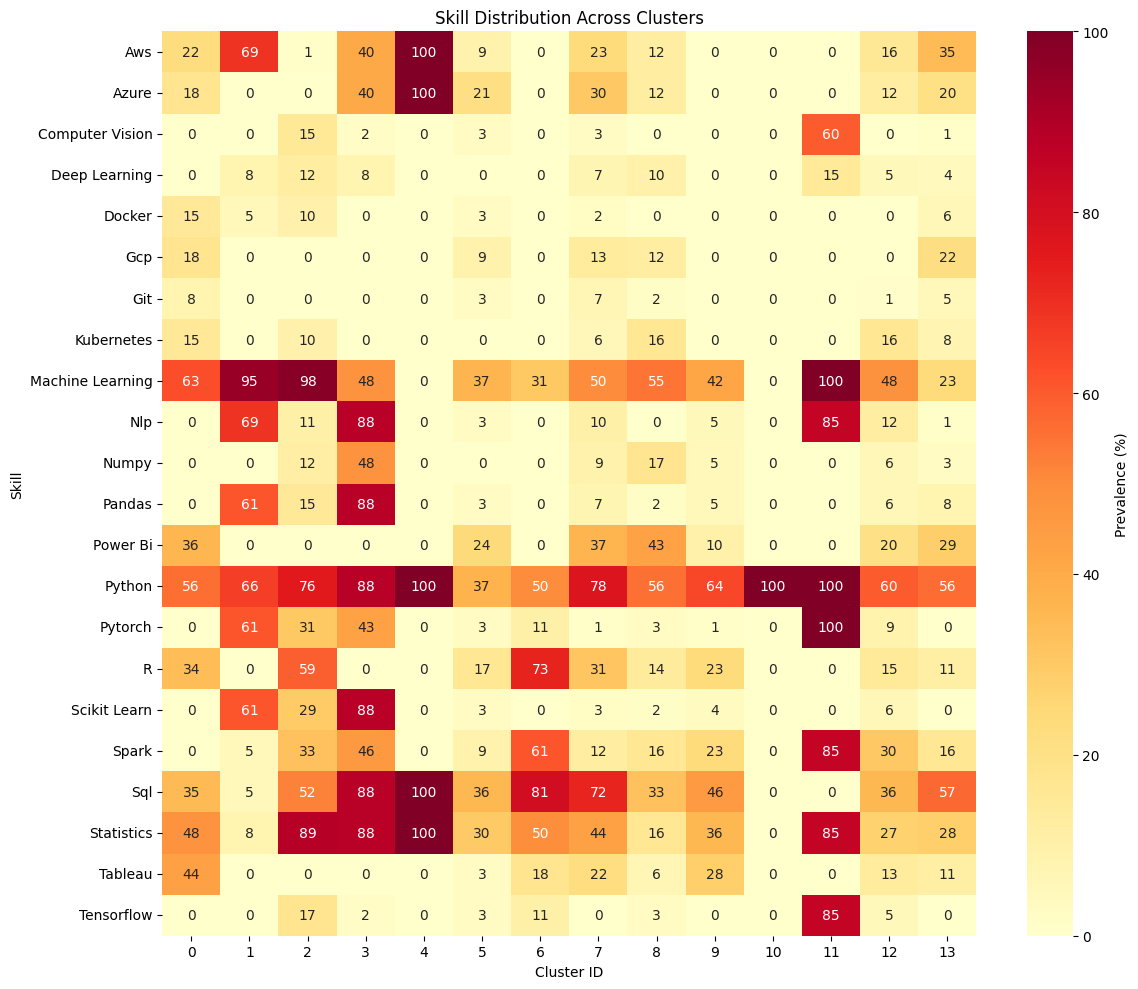

In [24]:
# Visualization: Skill heatmap by cluster
plt.figure(figsize=(12, 10))
sns.heatmap(skill_pivot.fillna(0), annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Prevalence (%)'})
plt.title('Skill Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

In [25]:
# Cosine similarity between cluster skill profiles
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity

# Convert skill prevalence to vectors
skill_vectors = skill_pivot.fillna(0).T.values

# Compute cosine similarity
cosine_sim = cosine_similarity(skill_vectors)
cosine_sim_df = pd.DataFrame(cosine_sim, 
                             index=skill_pivot.columns,
                             columns=skill_pivot.columns)

print("\nCosine Similarity Between Cluster Skill Profiles:")
print(cosine_sim_df.round(3))


Cosine Similarity Between Cluster Skill Profiles:
Cluster     0      1      2      3      4      5      6      7      8      9   \
Cluster                                                                         
0        1.000  0.496  0.794  0.540  0.621  0.906  0.689  0.914  0.873  0.869   
1        0.496  1.000  0.618  0.761  0.358  0.519  0.291  0.515  0.549  0.498   
2        0.794  0.618  1.000  0.726  0.530  0.848  0.816  0.810  0.773  0.870   
3        0.540  0.761  0.726  1.000  0.639  0.682  0.577  0.705  0.593  0.677   
4        0.621  0.358  0.530  0.639  1.000  0.738  0.545  0.769  0.554  0.612   
5        0.906  0.519  0.848  0.682  0.738  1.000  0.770  0.970  0.911  0.882   
6        0.689  0.291  0.816  0.577  0.545  0.770  1.000  0.791  0.651  0.862   
7        0.914  0.515  0.810  0.705  0.769  0.970  0.791  1.000  0.910  0.921   
8        0.873  0.549  0.773  0.593  0.554  0.911  0.651  0.910  1.000  0.841   
9        0.869  0.498  0.870  0.677  0.612  0.882  0.862  

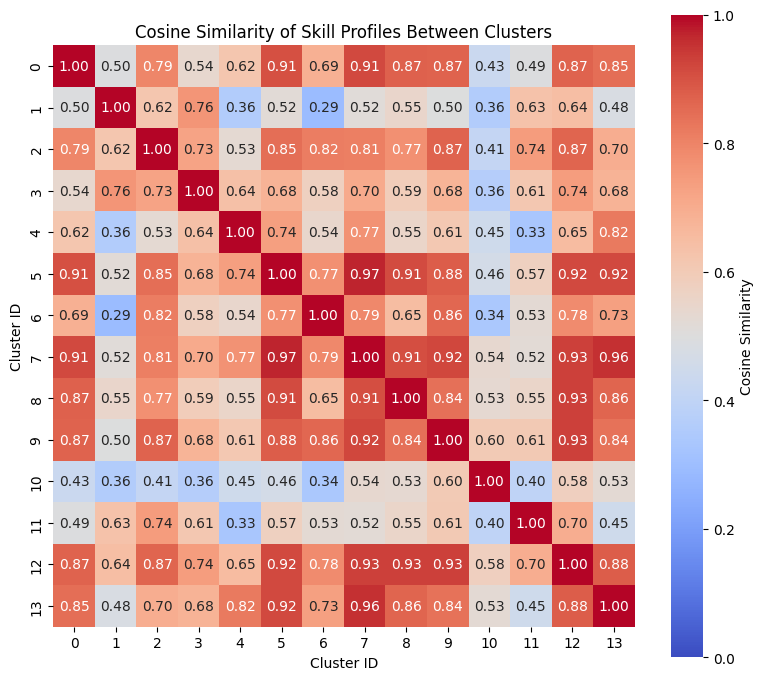

In [26]:
# Visualization: Cluster similarity heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(cosine_sim_df, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0.5, vmin=0, vmax=1, square=True,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('Cosine Similarity of Skill Profiles Between Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

## Visualization and Results

- Create PCA visualization to show clusters in 2D space
- Generate summary statistics of clustering results
- Display key insights about identified micro professions
- Export results and cluster interpretations for further use

In [27]:
# PCA visualization of clusters
from sklearn.decomposition import PCA
from IPython.display import display

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

# Create interactive scatter plot
scatter_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df_filtered['kmeans_cluster'],
    'Title': df_filtered[title_col],
    'Date': df_filtered['parsed_date']
})

fig = px.scatter(scatter_df, x='PC1', y='PC2', color='Cluster', 
                 hover_data=['Title', 'Date'],
                 title='Job Description Embeddings (PCA Projection)',
                 labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', 
                         'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'},
                 color_continuous_scale='Viridis')

display(fig)
print(f"Scatter plot created with {len(scatter_df)} data points across {scatter_df['Cluster'].nunique()} clusters")

PCA Explained Variance Ratio: [0.1625107  0.08768511]
Total Variance Explained: 25.02%


Scatter plot created with 5001 data points across 14 clusters


In [30]:
# Summary statistics

print("Initial research findings")


print(f"\nDataset Overview:")
print(f"  Total postings analyzed: {len(df_filtered)}")
print(f"  Date range: {df_filtered['parsed_date'].min().date()} to {df_filtered['parsed_date'].max().date()}")
print(f"  Number of quarters: {df_filtered['year_quarter'].nunique()}")

print(f"\nClustering Results (K Means with k={best_k}):")
print(f"  Silhouette Score: {best_silhouette:.3f}")
print(f"  Davies Bouldin Index: {kmeans_df[kmeans_df['k']==best_k]['davies_bouldin'].values[0]:.3f}")
print(f"  Calinski Harabasz Index: {kmeans_df[kmeans_df['k']==best_k]['calinski_harabasz'].values[0]:.1f}")

print(f"\nCluster Stability:")
for _, row in cluster_stats_df.head(5).iterrows():
    print(f"  Cluster {row['cluster_id']}: {row['total_postings']} postings, " 
          f"Lifespan: {row['lifespan_quarters']} quarters, Volatility: {row['volatility']:.1f}")

print(f"\nKey Insights:")
print(f"  Distinct micro professions identified: {len(cluster_interpretations)}")
print(f"  Skill diversity across clusters: High (see heatmap)")
print(f"  Most stable cluster: {cluster_stats_df.iloc[0]['cluster_id']}")
print(f"  Mean cluster size: {df_filtered['kmeans_cluster'].value_counts().mean():.0f} postings")
print(f"  Std cluster size: {df_filtered['kmeans_cluster'].value_counts().std():.0f} postings")

Initial research findings

Dataset Overview:
  Total postings analyzed: 5001
  Date range: 2025-12-06 to 2026-01-03
  Number of quarters: 2

Clustering Results (K Means with k=14):
  Silhouette Score: 0.316
  Davies Bouldin Index: 2.149
  Calinski Harabasz Index: 306.5

Cluster Stability:
  Cluster 4: 893.0 postings, Lifespan: 1 quarters, Volatility: 611.6
  Cluster 13: 791.0 postings, Lifespan: 0 quarters, Volatility: 0.0
  Cluster 12: 491.0 postings, Lifespan: 1 quarters, Volatility: 297.7
  Cluster 7: 490.0 postings, Lifespan: 1 quarters, Volatility: 333.8
  Cluster 8: 361.0 postings, Lifespan: 1 quarters, Volatility: 245.4

Key Insights:
  Distinct micro professions identified: 14
  Skill diversity across clusters: High (see heatmap)
  Most stable cluster: 4
  Mean cluster size: 357 postings
  Std cluster size: 238 postings


In [41]:
# Export results for further analysis

# Save main dataframe with cluster assignments
export_df = df_filtered[[
    title_col, 'parsed_date', 'year_quarter', 'year_month',
    'kmeans_cluster', 'dbscan_cluster', 'cleaned_description'
]].copy()

# Export clustered jobs
export_df.to_csv('clustered_jobs.csv', index=False)
print(f"Exported {len(export_df)} clustered jobs to: clustered_jobs.csv")

# Save cluster interpretations
interp_export = []
for cluster_id, info in cluster_interpretations.items():
    interp_export.append({
        'Cluster ID': cluster_id,
        'Label': cluster_labels.get(cluster_id, f"Cluster {cluster_id}"),
        'Top Terms': ' | '.join(info['top_terms']),
        'Size': info['size']
    })

interp_df = pd.DataFrame(interp_export)
interp_df.to_csv('cluster_interpretations.csv', index=False)
print(f"Exported {len(interp_df)} cluster interpretations to: cluster_interpretations.csv")

Exported 5001 clustered jobs to: clustered_jobs.csv
Exported 14 cluster interpretations to: cluster_interpretations.csv


## Cluster Analysis and Domain Interpretation

- Load exported cluster interpretations and job postings
- Examine sample jobs from each cluster to validate TF-IDF terms
- Identify company patterns and domain specializations
- Assign semantic labels based on actual job content


In [45]:
# Load exported cluster data for analysis
interp_loaded = pd.read_csv('cluster_interpretations.csv')
clustered_jobs_loaded = pd.read_csv('clustered_jobs.csv')

print("Cluster Interpretations Summary:")
print(interp_loaded.to_string(index=False))
print(f"\nClustered Jobs Dataset Shape: {clustered_jobs_loaded.shape}")
print(f"Columns: {clustered_jobs_loaded.columns.tolist()}")


Cluster Interpretations Summary:
 Cluster ID      Label                                                                                              Top Terms  Size
          0  Cluster 0                     data | ai | experience | peraton | 000 | work | position | benefits | risk | years   245
          1  Cluster 1                   ai | ml | kensho | data | lensa | models | team | technical | solutions | experience   275
          2  Cluster 2      data | learning | tiktok | ai | machine learning | machine | work | product | experience | models   249
          3  Cluster 3                data | ibm | business | science | technical | ai | experience | learning | lensa | work   304
          4  Cluster 4                        data | role | lensa | job | time | customer | work | paid | position | patterns   893
          5  Cluster 5                           data | lensa | job | waystar | work | jobs | information | new | york | team   323
          6  Cluster 6 data | tiktok | expe

In [46]:
# Sample job postings from each cluster to validate interpretations
print("Sample Job Postings by Cluster:")
print("="*80)

for cluster_id in range(best_k):
    cluster_jobs = clustered_jobs_loaded[clustered_jobs_loaded['kmeans_cluster'] == cluster_id]
    
    if len(cluster_jobs) > 0:
        sample_idx = cluster_jobs.sample(1, random_state=42).index[0]
        sample_job = clustered_jobs_loaded.loc[sample_idx]
        
        top_terms = interp_loaded[interp_loaded['Cluster ID'] == cluster_id]['Top Terms'].values[0]
        
        print(f"\nCluster {cluster_id} ({len(cluster_jobs)} total jobs)")
        print(f"Top Terms: {top_terms}")
        print(f"Job Title: {sample_job['job_title']}")
        print(f"Description Preview: {sample_job['cleaned_description'][:300]}...")
        print("-"*80)


Sample Job Postings by Cluster:

Cluster 0 (245 total jobs)
Top Terms: data | ai | experience | peraton | 000 | work | position | benefits | risk | years
Job Title: Data Engineer / Backend Developer with OpenShift and Kubernetes
Description Preview: Pay found in job postRetrieved from the description.Base pay range$112,000.00/yr - $179,000.00/yrAbout PeratonPeraton is a next-generation national security company that drives missions of consequence spanning the globe and extending to the farthest reaches of the galaxy. As the world's leading miss...
--------------------------------------------------------------------------------

Cluster 1 (275 total jobs)
Top Terms: ai | ml | kensho | data | lensa | models | team | technical | solutions | experience
Job Title: Machine Learning Intern - Summer 2026
Description Preview: Kensho is S&P Global’s hub for AI innovation and transformation. With expertise in machine learning, natural language processing, and data discovery, we develop and deploy

In [47]:
# Create semantic domain mappings based on analysis
domain_labels = {
    0: 'Core Data Analyst - Risk/Compliance',
    1: 'AI/ML Model Development',
    2: 'Product-Focused ML Engineer',
    3: 'Enterprise Data Science (IBM)',
    4: 'Junior Data Analyst/Intern',
    5: 'Data Analytics Engineer',
    6: 'Creative/Media Data Analytics',
    7: 'Data Engineering and Programs',
    8: 'Business Intelligence Analyst',
    9: 'Analytics and Influencer Marketing',
    10: 'Real-time Sports Analytics',
    11: 'ML Systems and Infrastructure',
    12: 'Internship/Entry-Level ML',
    13: 'General Business Data Analyst',
}

print("Updated Cluster Labels with Domain Interpretation:\n")
for cluster_id, label in domain_labels.items():
    cluster_size = interp_loaded[interp_loaded['Cluster ID'] == cluster_id]['Size'].values[0]
    print(f"Cluster {cluster_id:2d} ({cluster_size:4d} jobs): {label}")


Updated Cluster Labels with Domain Interpretation:

Cluster  0 ( 245 jobs): Core Data Analyst - Risk/Compliance
Cluster  1 ( 275 jobs): AI/ML Model Development
Cluster  2 ( 249 jobs): Product-Focused ML Engineer
Cluster  3 ( 304 jobs): Enterprise Data Science (IBM)
Cluster  4 ( 893 jobs): Junior Data Analyst/Intern
Cluster  5 ( 323 jobs): Data Analytics Engineer
Cluster  6 ( 147 jobs): Creative/Media Data Analytics
Cluster  7 ( 490 jobs): Data Engineering and Programs
Cluster  8 ( 361 jobs): Business Intelligence Analyst
Cluster  9 ( 232 jobs): Analytics and Influencer Marketing
Cluster 10 (  90 jobs): Real-time Sports Analytics
Cluster 11 ( 110 jobs): ML Systems and Infrastructure
Cluster 12 ( 491 jobs): Internship/Entry-Level ML
Cluster 13 ( 791 jobs): General Business Data Analyst


In [48]:
# Categorize clusters into macro job categories
macro_categories = {
    'Entry-Level/Internship': [4, 12],
    'Analytics': [0, 5, 9, 13],
    'ML/AI Engineering': [1, 2, 11],
    'Specialized Domain': [3, 8, 10],
    'Creative/Product': [6],
    'Data Engineering': [7],
}

print("Macro Job Categories:\n")
for category, cluster_ids in macro_categories.items():
    total_jobs = sum(interp_loaded[interp_loaded['Cluster ID'].isin(cluster_ids)]['Size'].values)
    percentage = (total_jobs / len(clustered_jobs_loaded)) * 100
    print(f"{category:25s}: {total_jobs:5d} jobs ({percentage:5.1f}%) - Clusters {cluster_ids}")


Macro Job Categories:

Entry-Level/Internship   :  1384 jobs ( 27.7%) - Clusters [4, 12]
Analytics                :  1591 jobs ( 31.8%) - Clusters [0, 5, 9, 13]
ML/AI Engineering        :   634 jobs ( 12.7%) - Clusters [1, 2, 11]
Specialized Domain       :   755 jobs ( 15.1%) - Clusters [3, 8, 10]
Creative/Product         :   147 jobs (  2.9%) - Clusters [6]
Data Engineering         :   490 jobs (  9.8%) - Clusters [7]


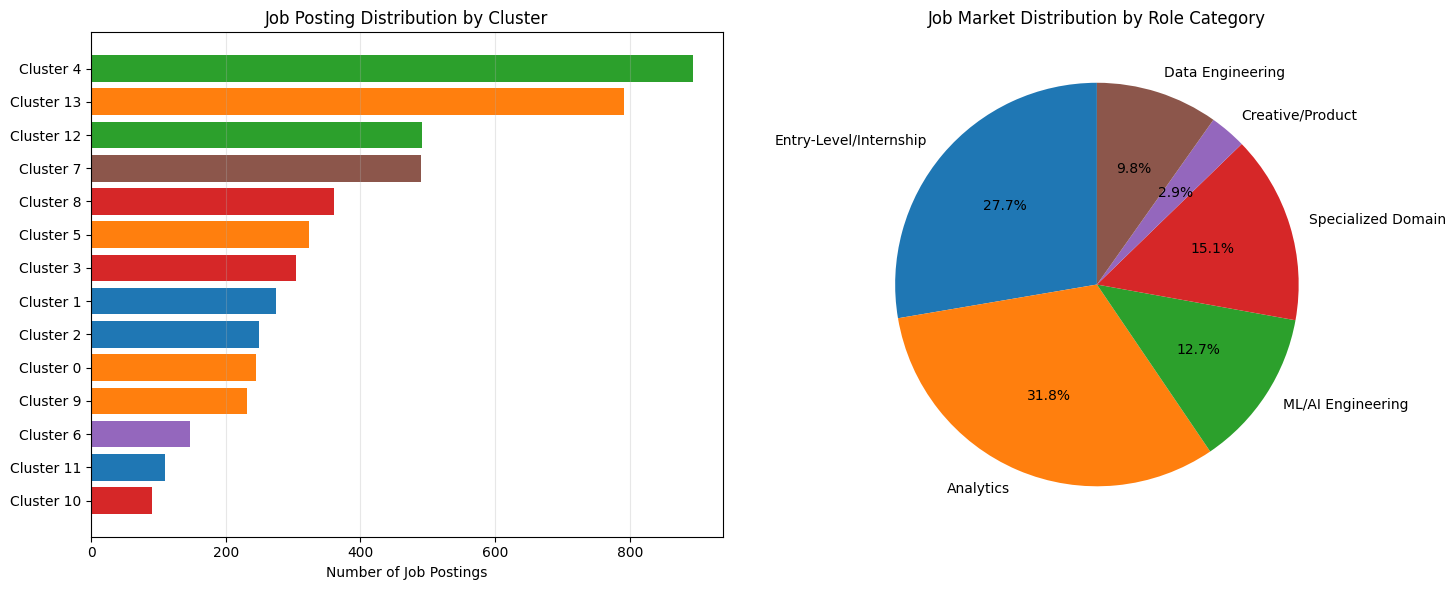

In [50]:
# Visualization: Cluster size distribution and macro categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Cluster sizes with color coding by category
cluster_data = interp_loaded.sort_values('Size', ascending=True)
colors = []
for cid in cluster_data['Cluster ID']:
    if cid in macro_categories['ML/AI Engineering']:
        colors.append('#1f77b4')
    elif cid in macro_categories['Analytics']:
        colors.append('#ff7f0e')
    elif cid in macro_categories['Entry-Level/Internship']:
        colors.append('#2ca02c')
    elif cid in macro_categories['Specialized Domain']:
        colors.append('#d62728')
    elif cid in macro_categories['Creative/Product']:
        colors.append('#9467bd')
    else:
        colors.append('#8c564b')

ax1.barh(range(len(cluster_data)), cluster_data['Size'], color=colors)
ax1.set_yticks(range(len(cluster_data)))
ax1.set_yticklabels([f"Cluster {int(cid)}" for cid in cluster_data['Cluster ID']])
ax1.set_xlabel('Number of Job Postings')
ax1.set_title('Job Posting Distribution by Cluster')
ax1.grid(axis='x', alpha=0.3)

# Chart 2: Macro categories pie chart
category_sizes = []
category_labels = []

for category, cluster_ids in macro_categories.items():
    total = sum(interp_loaded[interp_loaded['Cluster ID'].isin(cluster_ids)]['Size'].values)
    category_sizes.append(total)
    category_labels.append(category)

category_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
ax2.pie(category_sizes, labels=category_labels, autopct='%1.1f%%', colors=category_colors, startangle=90)
ax2.set_title('Job Market Distribution by Role Category')

plt.tight_layout()
plt.show()
